In [ ]:
import numpy as np
import pandas as pd
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, multilabel_confusion_matrix
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cpu


In [ ]:
df = pd.read_csv("cellula toxic data.csv")  # update path if needed


print(df.shape)
df.head()

(159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
TARGET_COL = "toxic"
df[TARGET_COL].value_counts(normalize=True)

toxic
0    0.904156
1    0.095844
Name: proportion, dtype: float64

In [4]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
SUBSAMPLE_SIZE = 40000
df = df.sample(n=SUBSAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
print(df.shape)

(40000, 8)


In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # urls
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)              # punctuation/symbols
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["comment_text"].apply(clean_text)
df["clean_text"].head()

0    geez are you forgetful we ve already discussed...
1    carioca rfa thanks for your support on my requ...
2    birthday no worries it s what i do enjoy ur da...
3    pseudoscience category i m assuming that this ...
4    and if such phrase exists it would be provided...
Name: clean_text, dtype: str

count    40000.000000
mean        68.113250
std        100.430319
min          0.000000
25%         17.000000
50%         37.000000
75%         76.000000
max       1356.000000
Name: clean_text, dtype: float64


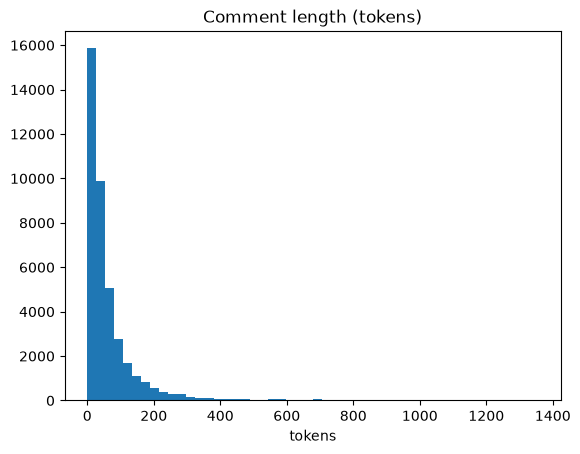

In [7]:
lengths = df["clean_text"].apply(lambda x: len(x.split()))
print(lengths.describe())
plt.hist(lengths, bins=50)
plt.title("Comment length (tokens)")
plt.xlabel("tokens")
plt.show()

In [8]:
from collections import Counter

MAX_VOCAB = 20000
MAX_LEN = 120

counter = Counter()
for text in df["clean_text"]:
    counter.update(text.split())

most_common = counter.most_common(MAX_VOCAB - 2)  # reserve 0=PAD, 1=UNK
word2idx = {"<PAD>": 0, "<UNK>": 1}
for word, _ in most_common:
    word2idx[word] = len(word2idx)

vocab_size = len(word2idx)
print("Vocab size:", vocab_size)

def encode(text, max_len=MAX_LEN):
    tokens = text.split()[:max_len]
    ids = [word2idx.get(t, word2idx["<UNK>"]) for t in tokens]
    ids += [word2idx["<PAD>"]] * (max_len - len(ids))
    return ids

df["input_ids"] = df["clean_text"].apply(encode)

Vocab size: 20000


In [9]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)
print(train_df.shape, val_df.shape)

(32000, 10) (8000, 10)


In [10]:
class ToxicDataset(Dataset):
    def __init__(self, dataframe):
        self.inputs = np.stack(dataframe["input_ids"].values)
        self.labels = dataframe[TARGET_COL].values.astype(np.float32)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        x = torch.tensor(self.inputs[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

BATCH_SIZE = 64

train_ds = ToxicDataset(train_df)
val_ds = ToxicDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)  # (batch, MAX_LEN), (batch,)

torch.Size([64, 120]) torch.Size([64])


In [11]:
pos_count = train_df[TARGET_COL].sum()
neg_count = len(train_df) - pos_count
pos_weight = torch.tensor(neg_count / pos_count, dtype=torch.float32).to(device)
print(f"pos_weight: {pos_weight.item():.2f}")

pos_weight: 9.50


In [12]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_labels=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_labels)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.rnn(embedded)
        hidden = hidden.squeeze(0)
        logits = self.fc(hidden)      # (batch, 1)
        return logits.squeeze(1)      # (batch,) — matches label shape now

model = RNNClassifier(vocab_size=vocab_size).to(device)
print(model)

RNNClassifier(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (rnn): RNN(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [13]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 6

In [14]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    avg_loss = total_loss / len(loader.dataset)

    f1 = f1_score(all_targets, all_preds, zero_division=0)
    return avg_loss, f1, all_preds, all_targets

In [15]:
history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_val_f1 = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_f1, _, _ = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  -> new best model saved (val_f1={val_f1:.4f})")

model.load_state_dict(torch.load("best_model.pt"))
print(f"\nLoaded best model (val_f1={best_val_f1:.4f})")

Epoch 1/6 | train_loss=1.2540 | val_loss=1.2576 | val_f1=0.1827
  -> new best model saved (val_f1=0.1827)
Epoch 2/6 | train_loss=1.2496 | val_loss=1.2625 | val_f1=0.1752
Epoch 3/6 | train_loss=1.2551 | val_loss=1.2595 | val_f1=0.1742
Epoch 4/6 | train_loss=1.2464 | val_loss=1.2589 | val_f1=0.1668
Epoch 5/6 | train_loss=1.2347 | val_loss=1.2595 | val_f1=0.1652
Epoch 6/6 | train_loss=1.2303 | val_loss=1.2518 | val_f1=0.1838
  -> new best model saved (val_f1=0.1838)

Loaded best model (val_f1=0.1838)


In [16]:
final_val_loss, final_f1, final_preds, final_targets = evaluate(model, val_loader)

print(f"Final F1: {final_f1:.4f}  (target >= 0.75)")
print()
print(classification_report(final_targets, final_preds, target_names=["not_toxic", "toxic"], zero_division=0))

Final F1: 0.1838  (target >= 0.75)

              precision    recall  f1-score   support

   not_toxic       0.92      0.50      0.64      7226
       toxic       0.11      0.58      0.18       774

    accuracy                           0.51      8000
   macro avg       0.51      0.54      0.41      8000
weighted avg       0.84      0.51      0.60      8000



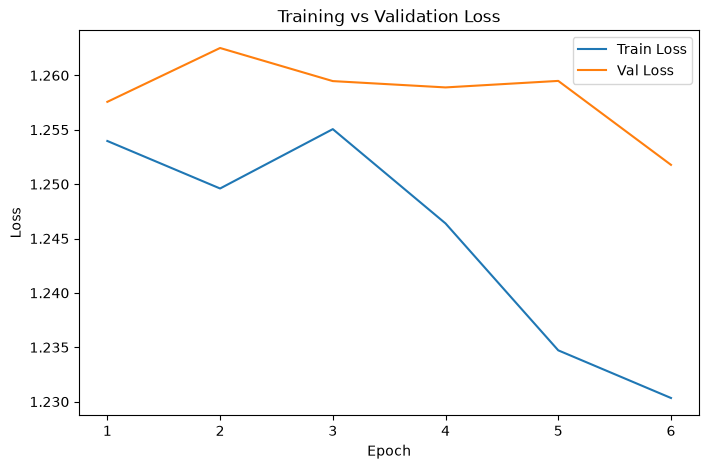

In [17]:
epochs_range = range(1, NUM_EPOCHS + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

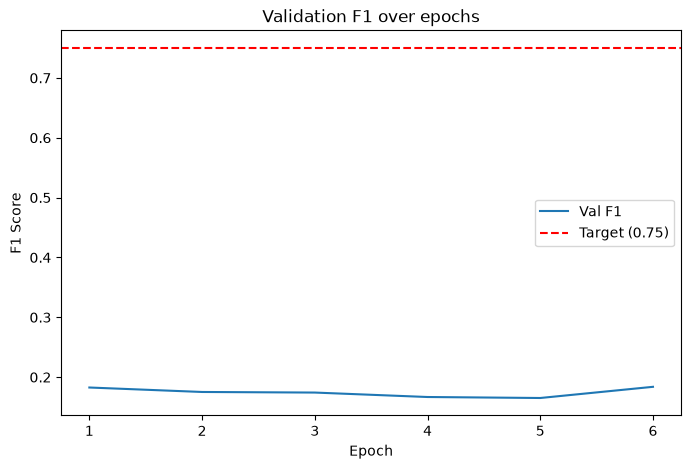

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["val_f1"], label="Val F1")
plt.axhline(y=0.75, color="r", linestyle="--", label="Target (0.75)")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 over epochs")
plt.legend()
plt.savefig("f1_curve.png", dpi=150, bbox_inches="tight")
plt.show()

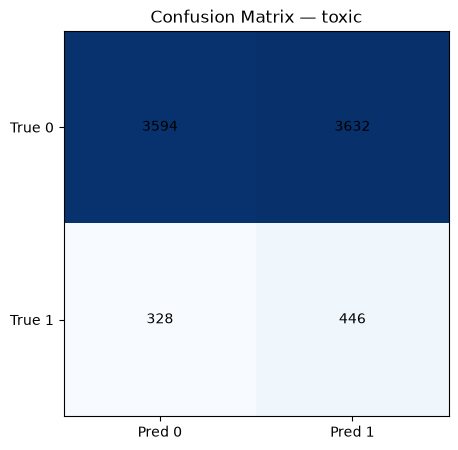

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(final_targets, final_preds)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix — toxic")
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
for r in range(2):
    for c in range(2):
        plt.text(c, r, cm[r, c], ha="center", va="center", color="black")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()